# Импорты и общие настройки

In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms
from pathlib import Path
import json

SEED = 42
DATASET = "EMNIST"

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('mps' if torch.mps.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)

device: mps
torch: 2.8.0


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])
train_full = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=False, download=True, transform=transform
)
class_names = train_full.classes
print("classes:", class_names)
print("class amount:", len(class_names))
print("train size:", len(train_full))
print("test size:", len(test_ds))

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
class amount: 47
train size: 112800
test size: 18800


In [3]:
BATCH_SIZE = 256 if device.type == "mps" else 64
NUM_WORKERS = 0 if os.name == "nt" else 2
val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size
gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "mps")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "mps")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "mps")
)
# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

/Users/wildcard/Projects/aie/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


x_batch: torch.Size([256, 1, 28, 28]) torch.float32
y_batch: torch.Size([256]) torch.int64


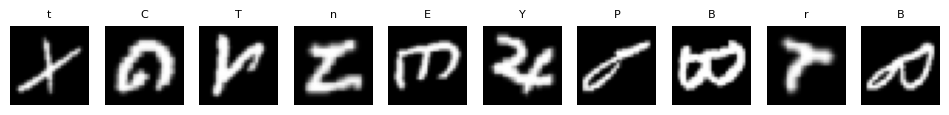

In [4]:
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [5]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([256, 10])


In [6]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()
def plot_history(history: dict, title: str = "", saveflag: bool = False, filename: Path = Path("")) -> None:
    # history ожидается вида:, 
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    if saveflag:
        plt.savefig(filename)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()
    
def plot_history4(history1: dict, history2: dict, title1: str = "", title2: str = "", saveflag: bool = False, filename: Path = Path("")) -> None:
    epochs = np.arange(1, len(history1["train_loss"]) + 1)
    fig, axs = plt.subplots(2,2)
    axs[0,0].plot(epochs, history1["train_loss"], label="train_loss")
    axs[0,0].plot(epochs, history1["val_loss"], label="val_loss")
    axs[0,0].set(xlabel="epoch", ylabel="loss")
    axs[0,0].set_title((title1 + " (loss)") if title1 else "loss")
    axs[0,0].legend()
    axs[0,0].grid(True)

    axs[1,0].plot(epochs, history1["train_acc"], label="train_acc")
    axs[1,0].plot(epochs, history1["val_acc"], label="val_acc")
    axs[1,0].set(xlabel="epoch", ylabel="accuracy")
    axs[1,0].set_title((title1 + " (accuracy)") if title1 else "accuracy")
    axs[1,0].legend()
    axs[1,0].grid(True)
    
    axs[0,1].plot(epochs, history2["train_loss"], label="train_loss")
    axs[0,1].plot(epochs, history2["val_loss"], label="val_loss")
    axs[0,1].set(xlabel="epoch", ylabel="loss")
    axs[0,1].set_title((title2 + " (loss)") if title2 else "loss")
    axs[0,1].legend()
    axs[0,1].grid(True)

    axs[1,1].plot(epochs, history2["train_acc"], label="train_acc")
    axs[1,1].plot(epochs, history2["val_acc"], label="val_acc")
    axs[1,1].set(xlabel="epoch", ylabel="accuracy")
    axs[1,1].set_title((title2 + " (accuracy)") if title2 else "accuracy")
    axs[1,1].legend()
    axs[1,1].grid(True)

    fig.set_figheight(20)
    fig.set_figwidth(40)
    if saveflag:
        plt.savefig(filename)
    fig.tight_layout()

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [8]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches
     

In [9]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [10]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

# Подготовка артефактов

In [11]:
artifacts_dir = Path("artifacts")
figures_dir = artifacts_dir / "figures"
def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
runs = []
def eval_run(
    eid, 
    model_desc, 
    optimizer, 
    lr, 
    epochs_trained, 
    best_val_accuracy, 
    best_val_loss,
    momentum=0, 
    weight_decay=0, 
    dataset=DATASET, 
    seed=SEED, 
):
    runs.append({
        "experiment_id":eid,
        "dataset":dataset,
        "seed":seed,
        "model_summary":model_desc,
        "optimizer":optimizer,
        "lr":lr,
        "momentum":momentum,
        "weight_decay":weight_decay,
        "epochs_trained":epochs_trained,
        "best_val_accuracy":best_val_accuracy,
        "best_val_loss":best_val_loss
    })

# E1

epoch 01/20 | train loss=1.6785, acc=0.5306 | val loss=1.0859, acc=0.6864
epoch 02/20 | train loss=0.9231, acc=0.7228 | val loss=0.8253, acc=0.7500
epoch 03/20 | train loss=0.7355, acc=0.7700 | val loss=0.7023, acc=0.7808
epoch 04/20 | train loss=0.6393, acc=0.7960 | val loss=0.6952, acc=0.7800
epoch 05/20 | train loss=0.5814, acc=0.8106 | val loss=0.6215, acc=0.8010
epoch 06/20 | train loss=0.5367, acc=0.8221 | val loss=0.5808, acc=0.8078
epoch 07/20 | train loss=0.5057, acc=0.8293 | val loss=0.5735, acc=0.8140
epoch 08/20 | train loss=0.4823, acc=0.8370 | val loss=0.5611, acc=0.8199
epoch 09/20 | train loss=0.4629, acc=0.8418 | val loss=0.5543, acc=0.8182
epoch 10/20 | train loss=0.4369, acc=0.8489 | val loss=0.5549, acc=0.8210
epoch 11/20 | train loss=0.4248, acc=0.8513 | val loss=0.5160, acc=0.8304
epoch 12/20 | train loss=0.4094, acc=0.8558 | val loss=0.5139, acc=0.8306
epoch 13/20 | train loss=0.3951, acc=0.8608 | val loss=0.5134, acc=0.8316
epoch 14/20 | train loss=0.3839, acc=0

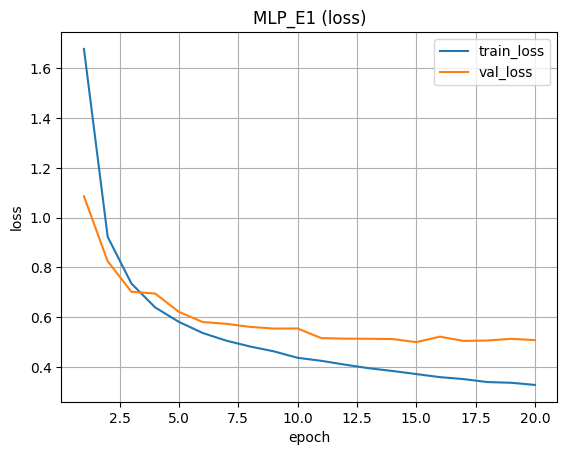

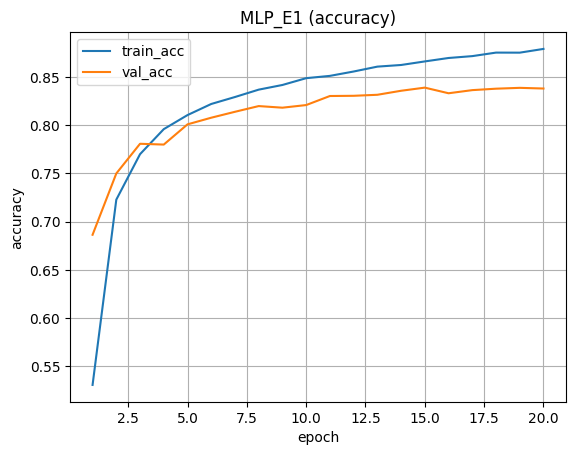

In [12]:
# 3 скрытых слоя без DropOut и BatchNorm
set_seed(42)
e1_mlp = MLP(hidden_dims=(256,128,64), num_classes=47, dropout_p=0.0, use_batchnorm=False).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(e1_mlp.parameters(), lr=1e-3)
history_e1 = fit(
    e1_mlp, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)
plot_history(history_e1, title="MLP_E1")
eval_run(eid="E1",
    model_desc="3 скрытых слоя (256,128,64) без DropOut и BatchNorm",
    optimizer="Adam",
    lr=1e-3,
    epochs_trained=20,
    best_val_accuracy=max(history_e1["val_acc"]),
    best_val_loss=min(history_e1["val_loss"])
)

# E2

epoch 01/20 | train loss=2.2296, acc=0.3706 | val loss=1.1444, acc=0.6603
epoch 02/20 | train loss=1.3666, acc=0.5867 | val loss=0.8987, acc=0.7185
epoch 03/20 | train loss=1.1864, acc=0.6416 | val loss=0.8095, acc=0.7446
epoch 04/20 | train loss=1.0875, acc=0.6665 | val loss=0.7538, acc=0.7628
epoch 05/20 | train loss=1.0208, acc=0.6850 | val loss=0.7125, acc=0.7717
epoch 06/20 | train loss=0.9794, acc=0.6955 | val loss=0.6712, acc=0.7870
epoch 07/20 | train loss=0.9406, acc=0.7074 | val loss=0.6588, acc=0.7887
epoch 08/20 | train loss=0.9219, acc=0.7125 | val loss=0.6462, acc=0.7916
epoch 09/20 | train loss=0.8981, acc=0.7208 | val loss=0.6255, acc=0.7965
epoch 10/20 | train loss=0.8704, acc=0.7283 | val loss=0.6116, acc=0.8023
epoch 11/20 | train loss=0.8607, acc=0.7292 | val loss=0.6068, acc=0.7978
epoch 12/20 | train loss=0.8458, acc=0.7348 | val loss=0.6000, acc=0.8040
epoch 13/20 | train loss=0.8257, acc=0.7400 | val loss=0.5853, acc=0.8076
epoch 14/20 | train loss=0.8178, acc=0

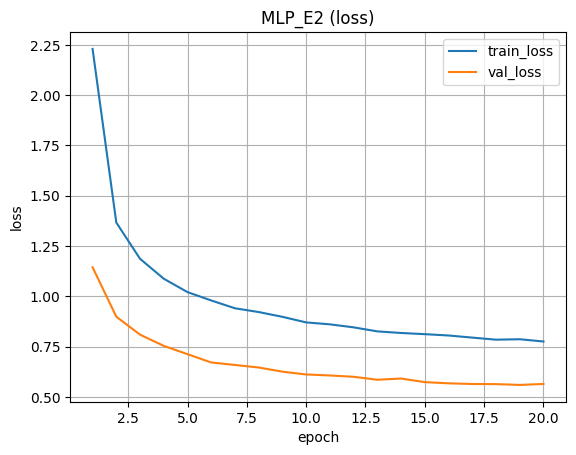

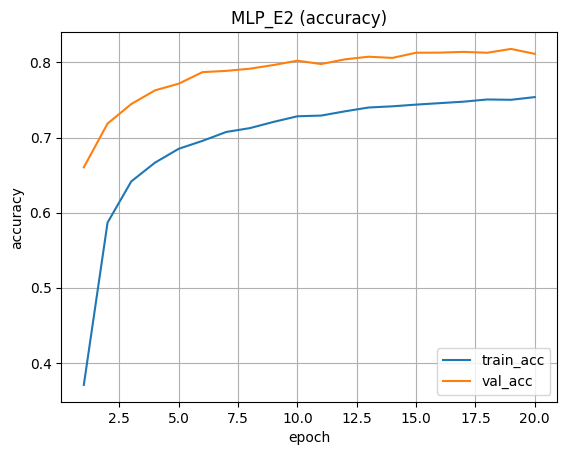

In [13]:
# 3 слоя 0.3 DropOut 
set_seed(42)
e2_mlp = MLP(hidden_dims=(256,128,64),num_classes=47, dropout_p=0.3, use_batchnorm=False).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(e2_mlp.parameters(), lr=1e-3)
history_e2 = fit(
    e2_mlp, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)
plot_history(history_e2, title="MLP_E2")
eval_run(eid="E2",
    model_desc="3 скрытых слоя (256,128,64) DropOut = 0.3",
    optimizer="Adam",
    lr=1e-3,
    epochs_trained=20,
    best_val_accuracy=max(history_e2["val_acc"]),
    best_val_loss=min(history_e2["val_loss"])
)

# E3

epoch 01/20 | train loss=1.3237, acc=0.6926 | val loss=0.6764, acc=0.7938
epoch 02/20 | train loss=0.5640, acc=0.8193 | val loss=0.5549, acc=0.8195
epoch 03/20 | train loss=0.4593, acc=0.8449 | val loss=0.5019, acc=0.8313
epoch 04/20 | train loss=0.4041, acc=0.8601 | val loss=0.4823, acc=0.8390
epoch 05/20 | train loss=0.3650, acc=0.8696 | val loss=0.4743, acc=0.8409
epoch 06/20 | train loss=0.3366, acc=0.8771 | val loss=0.4575, acc=0.8494
epoch 07/20 | train loss=0.3123, acc=0.8856 | val loss=0.4621, acc=0.8449
epoch 08/20 | train loss=0.2932, acc=0.8900 | val loss=0.4698, acc=0.8423
epoch 09/20 | train loss=0.2769, acc=0.8952 | val loss=0.4668, acc=0.8466
epoch 10/20 | train loss=0.2652, acc=0.8982 | val loss=0.4728, acc=0.8485
epoch 11/20 | train loss=0.2527, acc=0.9029 | val loss=0.4767, acc=0.8445
epoch 12/20 | train loss=0.2373, acc=0.9072 | val loss=0.4827, acc=0.8488
epoch 13/20 | train loss=0.2289, acc=0.9103 | val loss=0.4952, acc=0.8461
epoch 14/20 | train loss=0.2190, acc=0

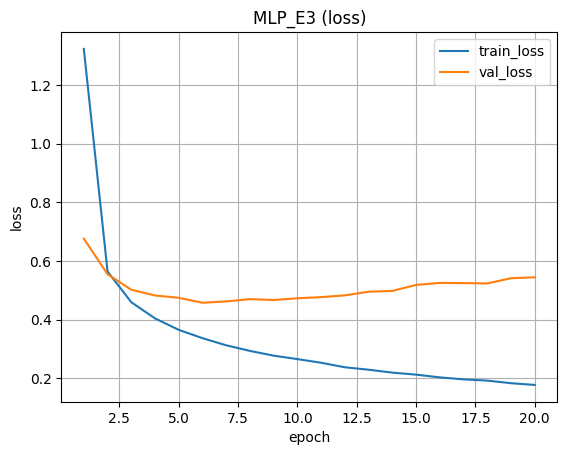

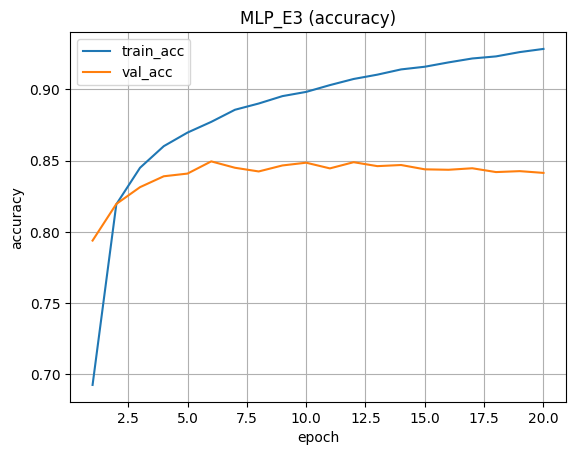

In [14]:
# 3 слоя и BatchNorm
set_seed(42)
e3_mlp = MLP(hidden_dims=(256,128,64), num_classes=47, dropout_p=0.0, use_batchnorm=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(e3_mlp.parameters(), lr=1e-3)
history_e3 = fit(
    e3_mlp, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)
plot_history(history_e3, title="MLP_E3")
eval_run(eid="E3",
    model_desc="3 скрытых слоя (256,128,64) BatchNorm = True",
    optimizer="Adam",
    lr=1e-3,
    epochs_trained=20,
    best_val_accuracy=max(history_e3["val_acc"]),
    best_val_loss=min(history_e3["val_loss"])
)

# E4

epoch 01/20 | train loss=1.3237, acc=0.6926 | val loss=0.6764, acc=0.7938
epoch 02/20 | train loss=0.5640, acc=0.8193 | val loss=0.5549, acc=0.8195
epoch 03/20 | train loss=0.4593, acc=0.8449 | val loss=0.5019, acc=0.8313
epoch 04/20 | train loss=0.4041, acc=0.8601 | val loss=0.4823, acc=0.8390
epoch 05/20 | train loss=0.3650, acc=0.8696 | val loss=0.4743, acc=0.8409
epoch 06/20 | train loss=0.3366, acc=0.8771 | val loss=0.4575, acc=0.8494
epoch 07/20 | train loss=0.3123, acc=0.8856 | val loss=0.4621, acc=0.8449
epoch 08/20 | train loss=0.2932, acc=0.8900 | val loss=0.4698, acc=0.8423
epoch 09/20 | train loss=0.2769, acc=0.8952 | val loss=0.4668, acc=0.8466
epoch 10/20 | train loss=0.2652, acc=0.8982 | val loss=0.4728, acc=0.8485
EarlyStopping: остановка на эпохе 10. Лучший val_acc=0.8494
saved to artifacts/best_model.pt size: 995509 bytes


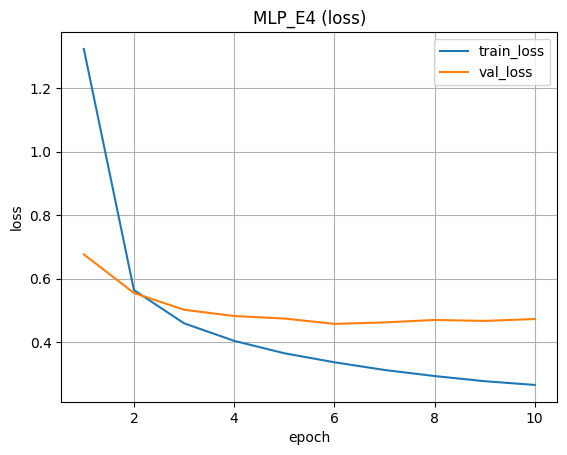

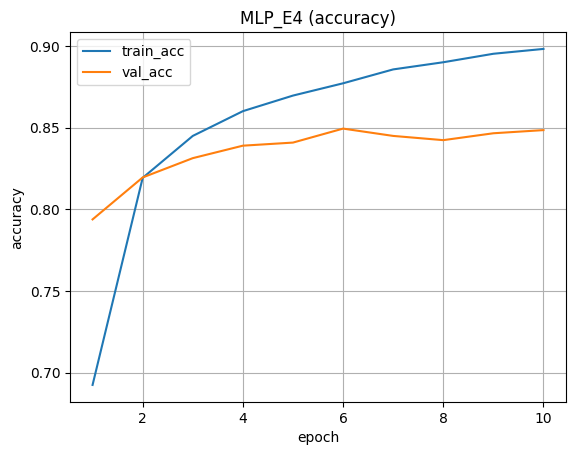

Test: loss=0.4733, acc=0.8420


In [15]:
# лучший по val_accuracy из E2 и E3 - E3
set_seed(42)
e4_mlp = MLP(hidden_dims=(256,128,64), num_classes=47, dropout_p=0.0, use_batchnorm=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(e4_mlp.parameters(), lr=1e-3)
es = EarlyStopping(patience=4, min_delta=0.0005)
history_e4 = fit(
    e4_mlp, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)
tmp_path = artifacts_dir / 'best_model.pt'
torch.save(e4_mlp.state_dict(), tmp_path)
print('saved to', tmp_path, 'size:', os.path.getsize(tmp_path), 'bytes')
plot_history(history_e4, title="MLP_E4", saveflag=True, filename=figures_dir / "curves_best.png")
test_loss, test_acc = evaluate(e4_mlp, test_loader, criterion, device)
print(f"Test: loss={test_loss:.4f}, acc={test_acc:.4f}")
eval_run(eid="E4",
    model_desc="3 скрытых слоя (256,128,64) BatchNorm = True, EarlyStopping, patience=4",
    optimizer="Adam",
    lr=1e-3,
    epochs_trained=len(history_e4["val_acc"]),
    best_val_accuracy=max(history_e4["val_acc"]),
    best_val_loss=min(history_e4["val_loss"])
)

# O1

In [16]:
def make_optimizer(model, kind, lr, weight_decay=0.0, momentum=0.9):
    kind = kind.lower().strip()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {kind}")

epoch 01/8 | train loss=1.0237, acc=0.6848 | val loss=0.7577, acc=0.7619
epoch 02/8 | train loss=0.6955, acc=0.7721 | val loss=0.6492, acc=0.7848
epoch 03/8 | train loss=0.6140, acc=0.7950 | val loss=0.6247, acc=0.8002
epoch 04/8 | train loss=0.5740, acc=0.8062 | val loss=0.5716, acc=0.8169
epoch 05/8 | train loss=0.5201, acc=0.8209 | val loss=0.6247, acc=0.7929
epoch 06/8 | train loss=0.4988, acc=0.8258 | val loss=0.5815, acc=0.8087
epoch 07/8 | train loss=0.4695, acc=0.8343 | val loss=0.5613, acc=0.8136
epoch 08/8 | train loss=0.4597, acc=0.8385 | val loss=0.5635, acc=0.8210


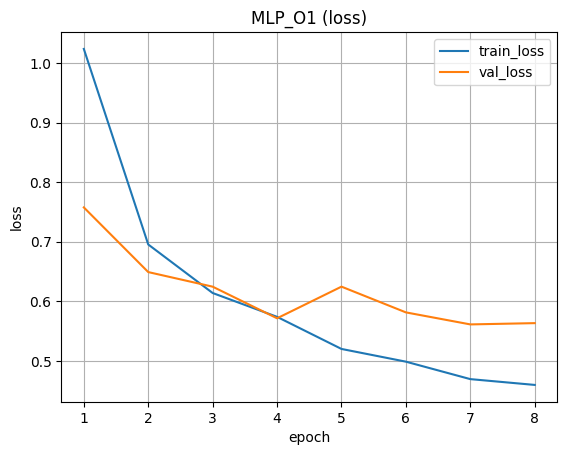

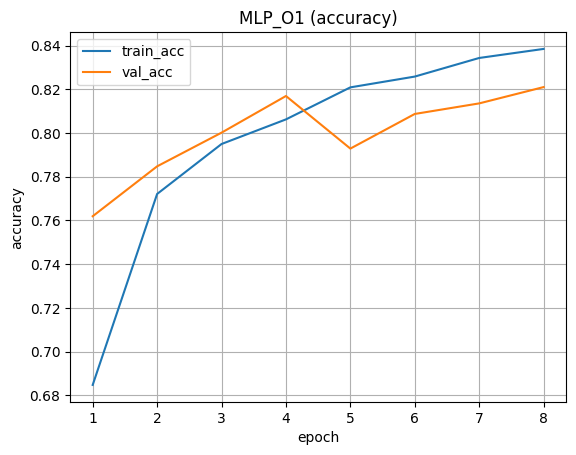

In [17]:
o1_mlp = MLP(hidden_dims=(256,128,64), num_classes=47, dropout_p=0.0, use_batchnorm=True).to(device)
opt = make_optimizer(o1_mlp, "adam", lr=1e-1, weight_decay=0.0, momentum=0)
history_o1 = fit(
    o1_mlp, train_loader, val_loader,
    opt, criterion, device,
    epochs=8,  # дадим больше эпох, но остановимся рано
    verbose=True
)
plot_history(history_o1, title="MLP_O1")
eval_run(eid="O1",
    model_desc="Аналогична E4 + 'слишком большой' lr = 1e-1",
    optimizer="Adam",
    lr=1e-1,
    epochs_trained=8,
    best_val_accuracy=max(history_o1["val_acc"]),
    best_val_loss=min(history_o1["val_loss"])
)

### По графикам можно увидеть плохое поведение метрик.

# O2

epoch 01/8 | train loss=3.6991, acc=0.0914 | val loss=3.4944, acc=0.1727
epoch 02/8 | train loss=3.3620, acc=0.2388 | val loss=3.2470, acc=0.2882
epoch 03/8 | train loss=3.1522, acc=0.3320 | val loss=3.0672, acc=0.3651
epoch 04/8 | train loss=2.9887, acc=0.3978 | val loss=2.9184, acc=0.4269
epoch 05/8 | train loss=2.8495, acc=0.4515 | val loss=2.7829, acc=0.4734
epoch 06/8 | train loss=2.7250, acc=0.4935 | val loss=2.6634, acc=0.5153
epoch 07/8 | train loss=2.6126, acc=0.5298 | val loss=2.5624, acc=0.5463
epoch 08/8 | train loss=2.5083, acc=0.5592 | val loss=2.4662, acc=0.5706


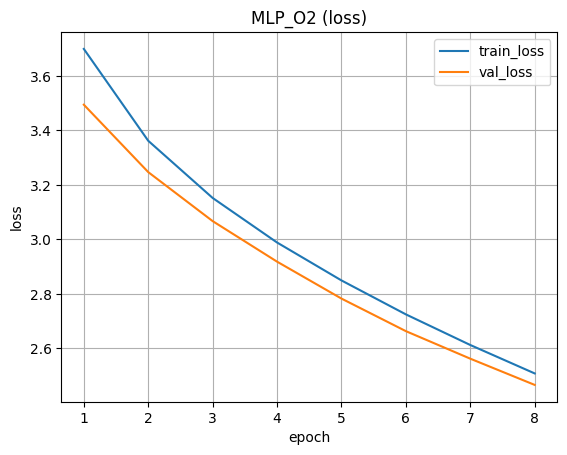

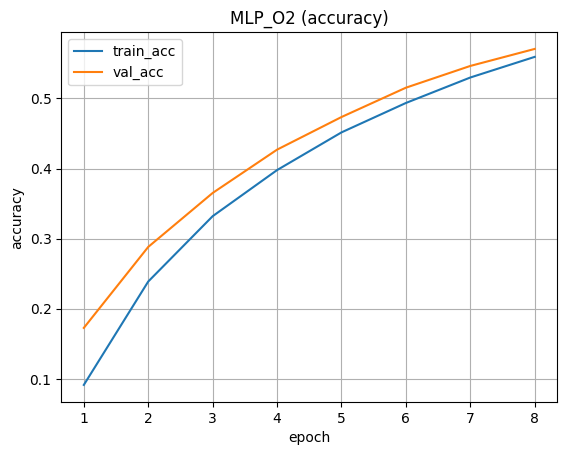

In [18]:
o2_mlp = MLP(hidden_dims=(256,128,64), num_classes=47, dropout_p=0.0, use_batchnorm=True).to(device)
opt = make_optimizer(o2_mlp, "adam", lr=1e-5, weight_decay=0.0, momentum=0)
history_o2 = fit(
    o2_mlp, train_loader, val_loader,
    opt, criterion, device,
    epochs=8,  # дадим больше эпох, но остановимся рано
    verbose=True
)
plot_history(history_o2, title="MLP_O2")
eval_run(eid="O2",
    model_desc="Аналогична E4 + 'слишком маленький' lr = 1e-5",
    optimizer="Adam",
    lr=1e-5,
    epochs_trained=8,
    best_val_accuracy=max(history_o2["val_acc"]),
    best_val_loss=min(history_o2["val_loss"])
)

# О3

epoch 01/15 | train loss=3.0736, acc=0.3486 | val loss=2.5406, acc=0.5107
epoch 02/15 | train loss=2.1772, acc=0.5817 | val loss=1.8469, acc=0.6303
epoch 03/15 | train loss=1.5951, acc=0.6691 | val loss=1.3920, acc=0.6906
epoch 04/15 | train loss=1.2322, acc=0.7186 | val loss=1.1162, acc=0.7348
epoch 05/15 | train loss=1.0122, acc=0.7524 | val loss=0.9564, acc=0.7581
epoch 06/15 | train loss=0.8706, acc=0.7766 | val loss=0.8458, acc=0.7742
epoch 07/15 | train loss=0.7749, acc=0.7919 | val loss=0.7741, acc=0.7875
epoch 08/15 | train loss=0.7034, acc=0.8069 | val loss=0.7184, acc=0.7987
epoch 09/15 | train loss=0.6493, acc=0.8174 | val loss=0.6750, acc=0.8061
epoch 10/15 | train loss=0.6051, acc=0.8269 | val loss=0.6456, acc=0.8103
epoch 11/15 | train loss=0.5695, acc=0.8336 | val loss=0.6221, acc=0.8136
epoch 12/15 | train loss=0.5394, acc=0.8407 | val loss=0.6006, acc=0.8194
epoch 13/15 | train loss=0.5129, acc=0.8470 | val loss=0.5845, acc=0.8215
epoch 14/15 | train loss=0.4907, acc=0

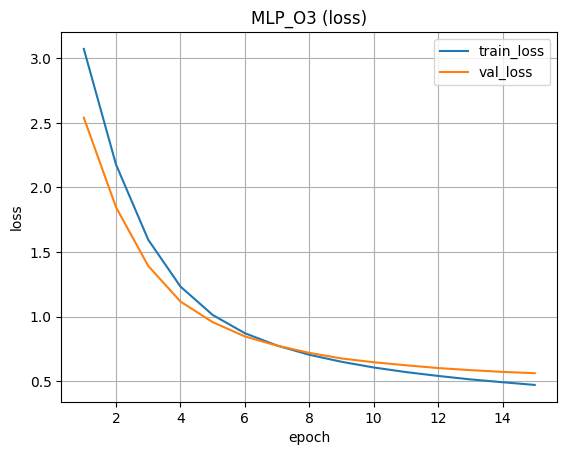

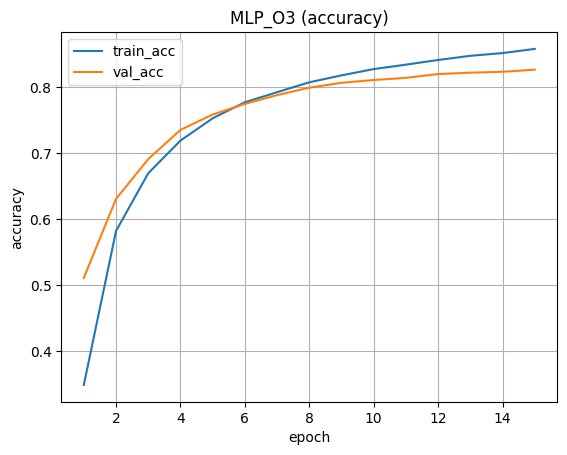

In [19]:
o3_mlp = MLP(hidden_dims=(256,128,64), num_classes=47, dropout_p=0.0, use_batchnorm=True).to(device)
opt = make_optimizer(o3_mlp, "sgd", lr=1e-3, weight_decay=1e-4, momentum=0.9)
history_o3 = fit(
    o3_mlp, train_loader, val_loader,
    opt, criterion, device,
    epochs=15,
    verbose=True
)
plot_history(history_o3, title="MLP_O3")
eval_run(eid="O3",
    model_desc="Аналогична E4 + SGD+MOMENTUM+WEIGHT_DECAY",
    optimizer="sgd",
    lr=1e-3,
    weight_decay=1e-4,
    momentum=0.9,
    epochs_trained=15,
    best_val_accuracy=max(history_o3["val_acc"]),
    best_val_loss=min(history_o3["val_loss"])
)

In [20]:
print(runs)

[{'experiment_id': 'E1', 'dataset': 'EMNIST', 'seed': 42, 'model_summary': '3 скрытых слоя (256,128,64) без DropOut и BatchNorm', 'optimizer': 'Adam', 'lr': 0.001, 'momentum': 0, 'weight_decay': 0, 'epochs_trained': 20, 'best_val_accuracy': 0.8390537219101124, 'best_val_loss': 0.4997928664925393}, {'experiment_id': 'E2', 'dataset': 'EMNIST', 'seed': 42, 'model_summary': '3 скрытых слоя (256,128,64) DropOut = 0.3', 'optimizer': 'Adam', 'lr': 0.001, 'momentum': 0, 'weight_decay': 0, 'epochs_trained': 20, 'best_val_accuracy': 0.8179424157303371, 'best_val_loss': 0.5596558870224471}, {'experiment_id': 'E3', 'dataset': 'EMNIST', 'seed': 42, 'model_summary': '3 скрытых слоя (256,128,64) BatchNorm = True', 'optimizer': 'Adam', 'lr': 0.001, 'momentum': 0, 'weight_decay': 0, 'epochs_trained': 20, 'best_val_accuracy': 0.8494118679775281, 'best_val_loss': 0.45747482475270046}, {'experiment_id': 'E4', 'dataset': 'EMNIST', 'seed': 42, 'model_summary': '3 скрытых слоя (256,128,64) BatchNorm = True, 

In [21]:
df_s = pd.DataFrame(runs)
display(df_s)
df_s.to_csv(artifacts_dir / "runs.csv", index=False)

,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,EMNIST,42,"3 скрытых слоя (256,128,64) без DropOut и Batc...",Adam,0.00100,0.0,0.0000,20,0.839054,0.499793
1,E2,EMNIST,42,"3 скрытых слоя (256,128,64) DropOut = 0.3",Adam,0.00100,0.0,0.0000,20,0.817942,0.559656
2,E3,EMNIST,42,"3 скрытых слоя (256,128,64) BatchNorm = True",Adam,0.00100,0.0,0.0000,20,0.849412,0.457475
3,E4,EMNIST,42,"3 скрытых слоя (256,128,64) BatchNorm = True, ...",Adam,0.00100,0.0,0.0000,10,0.849412,0.457475
4,O1,EMNIST,42,Аналогична E4 + 'слишком большой' lr = 1e-1,Adam,0.10000,0.0,0.0000,8,0.821015,0.561309
5,O2,EMNIST,42,Аналогична E4 + 'слишком маленький' lr = 1e-5,Adam,0.00001,0.0,0.0000,8,0.570576,2.466153
6,O3,EMNIST,42,Аналогична E4 + SGD+MOMENTUM+WEIGHT_DECAY,sgd,0.00100,0.9,0.0001,15,0.826018,0.560586


In [22]:
e4_desc_blob = {
    "experiment_id":"E4",
    "optimizer": "Adam",
    "lr":1e-3,
    "momentum":0,
    "weight_decay":0,
    "epochs_trained":len(history_e4["val_acc"]),
    "hidden_sizes": (256,128,64),
    "activation":"relu",
    "dropout":0.0,
    "batchnorm":True
}
save_json(e4_desc_blob,artifacts_dir / "best_config.json" )

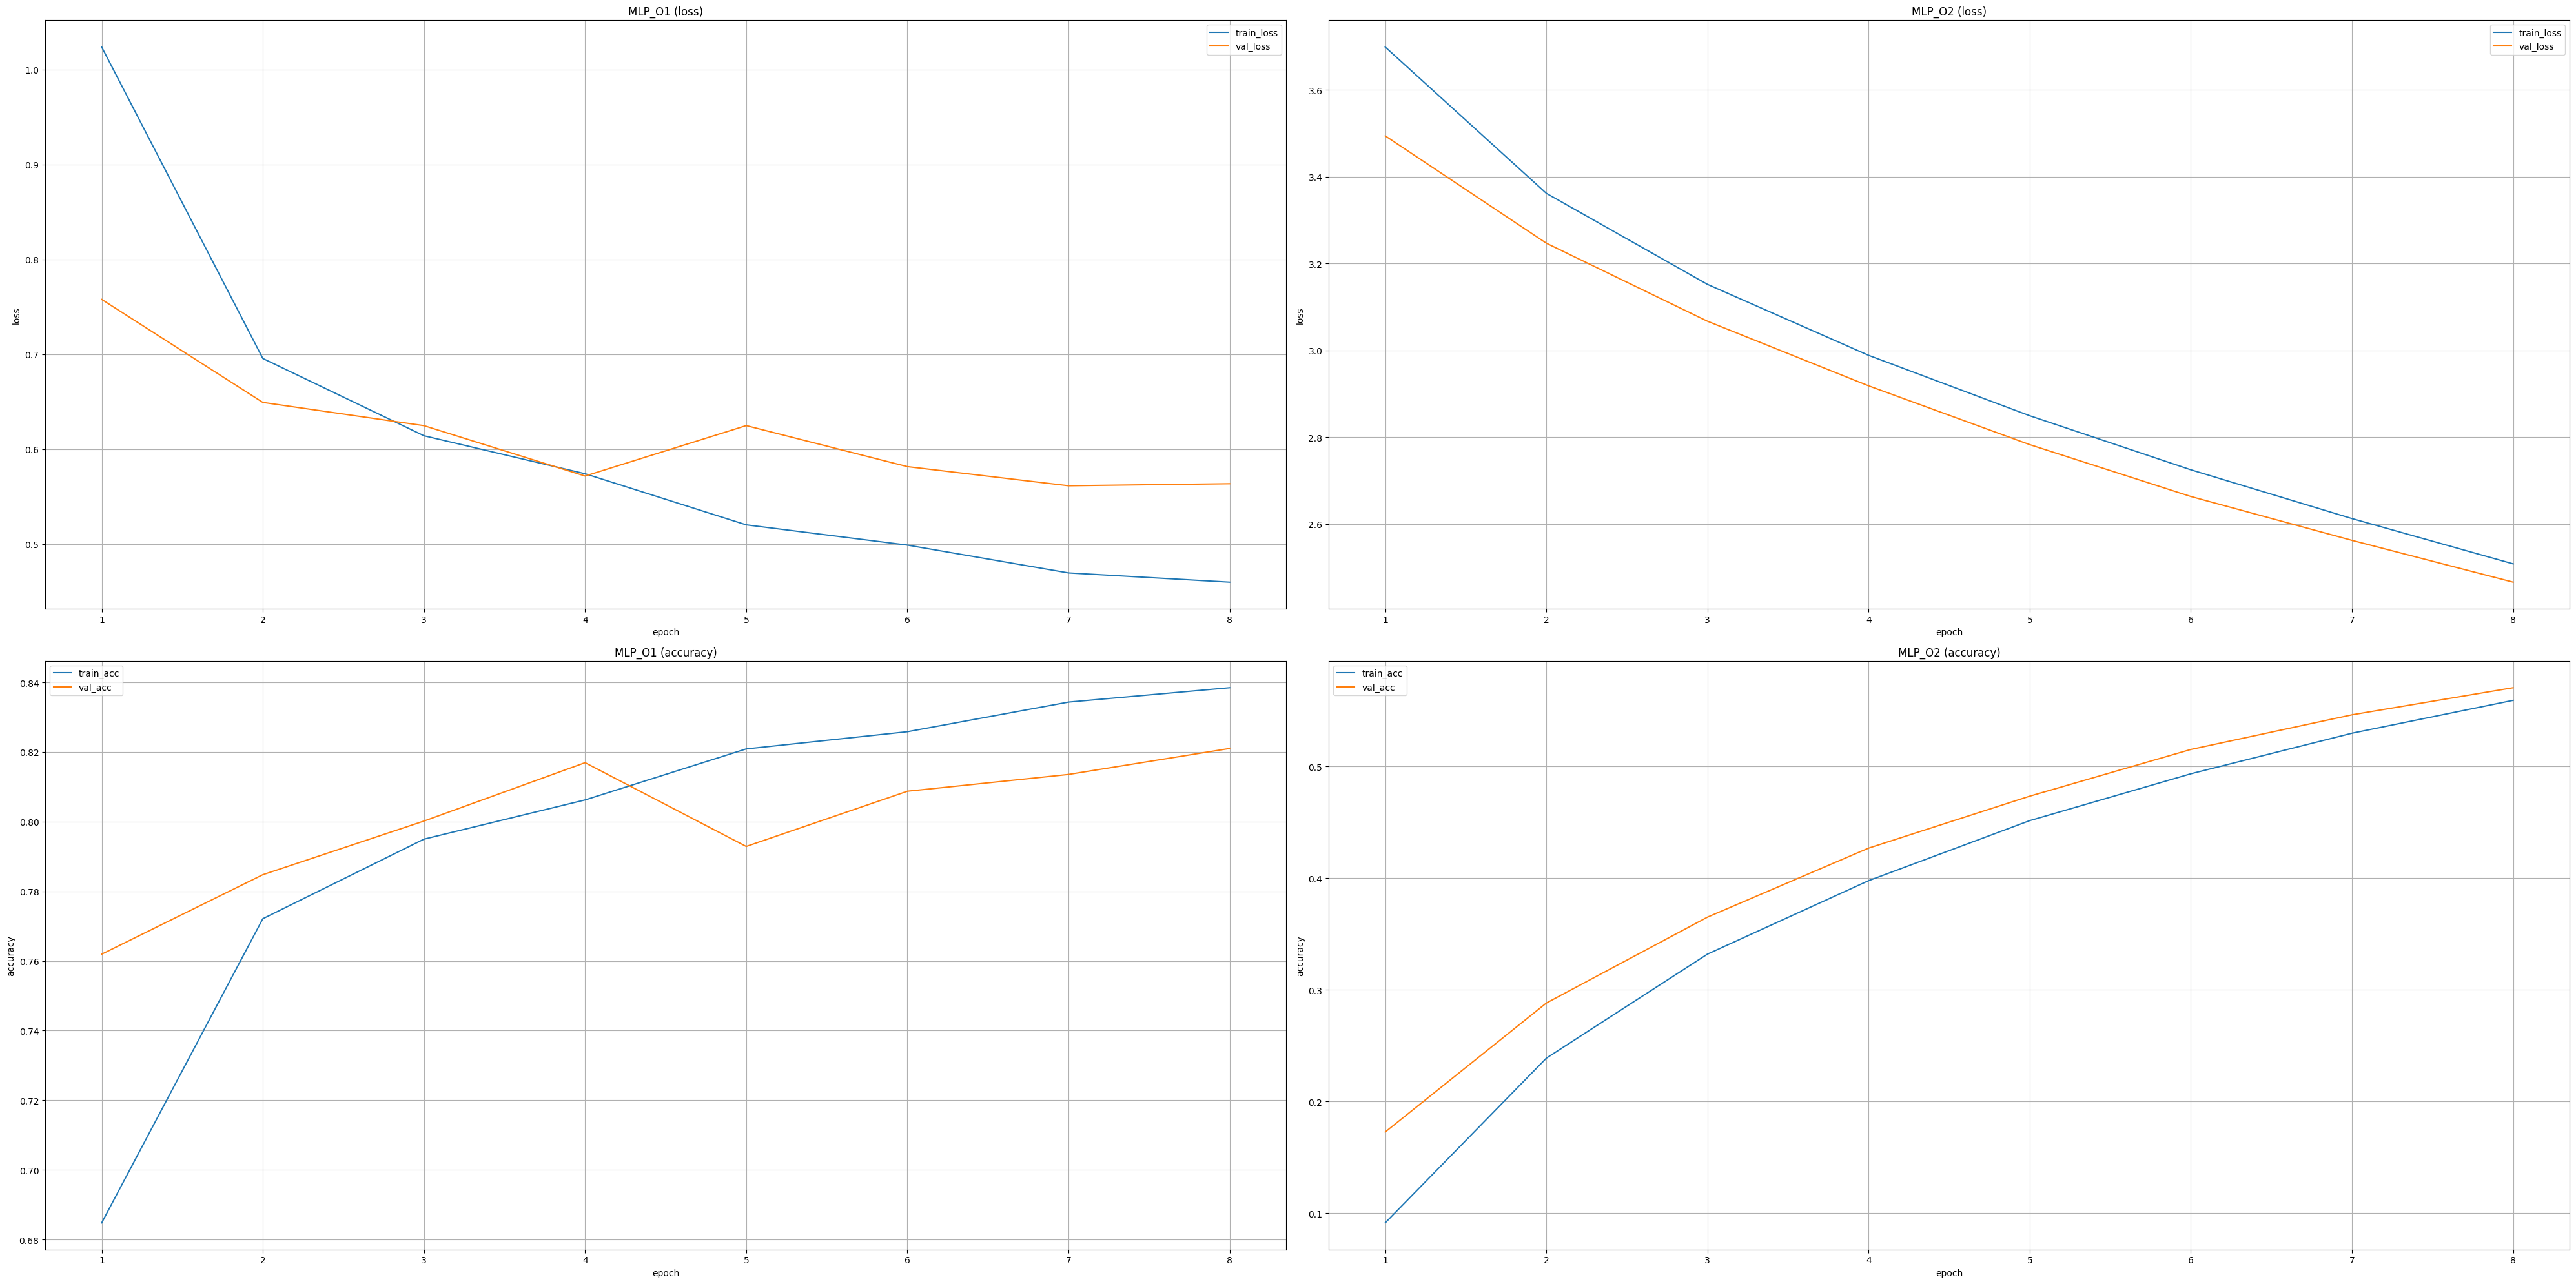

In [23]:
plot_history4(history_o1, history_o2, title1="MLP_O1", title2="MLP_O2", saveflag=True, filename=figures_dir / "curves_lr_extremes.png")